#### Importing Required Libraries

In [23]:
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

#### Loading the dataset

In [24]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

##### Dataset has 10 Classes

##### X_train = No. of Training images
##### y_train = Labels of Training images
##### X_test = No. of Testing images
##### y_test = Labels of Testing images

In [ ]:
print(f"Shape of X_train :{X_train.shape}") 
print(f"Shape of X_test :{X_test.shape}")
print(f"Shape of y_train :{y_train.shape}")
print(f"Shape of y_test:{y_test.shape}")

Shape of X_train :(60000, 28, 28)
Shape of X_test :(10000, 28, 28)
Shape of y_train :(60000,)
Shape of y_test:(10000,)


##### Example

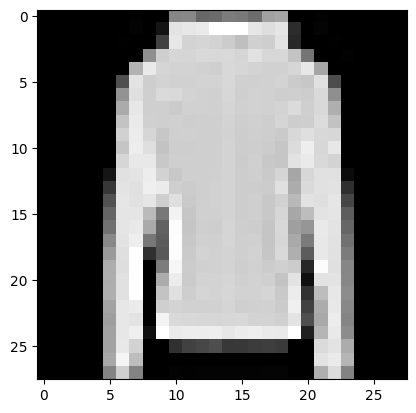

In [26]:
plt.imshow(X_train[40099],cmap='gray')
plt.show()

#### Reshaping the images

In [27]:
X_train = X_train.reshape(60000,28,28,1)
X_test = X_test.reshape(10000,28,28,1)

#### Model = Convolutional Neural Network(CNN)

In [28]:
model = Sequential()
model.add(Conv2D(128,(2,2),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(2,2),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(32,(2,2),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(100,activation='relu'))

model.add(Dense(50,activation='relu'))

model.add(Dense(10,activation='softmax'))

c:\Users\gball\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Summary of all parameters

In [29]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 27, 27, 128)    │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 5, 5, 32)       │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        12,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,156 (234.98 KB)

 Trainable params: 60,156 (234.98 KB)

 Non-trainable params: 0 (0.00 B)

#### Compilation of model

In [30]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Training of model

In [31]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 17ms/step - accuracy: 0.7883 - loss: 0.5919 - val_accuracy: 0.8185 - val_loss: 0.5051
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.8422 - loss: 0.4254 - val_accuracy: 0.8298 - val_loss: 0.4441
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.8583 - loss: 0.3788 - val_accuracy: 0.8481 - val_loss: 0.4098
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.8694 - loss: 0.3475 - val_accuracy: 0.8667 - val_loss: 0.3724
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.8776 - loss: 0.3267 - val_accuracy: 0.8694 - val_loss: 0.3618
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.8842 - loss: 0.3077 - val_accuracy: 0.8719 - val_loss: 0.3499
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.8870 - loss: 0.2960 - val_accuracy: 0.8744 - val_loss: 0.3483
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.8927 -

#### Graphical Representation of accuracy

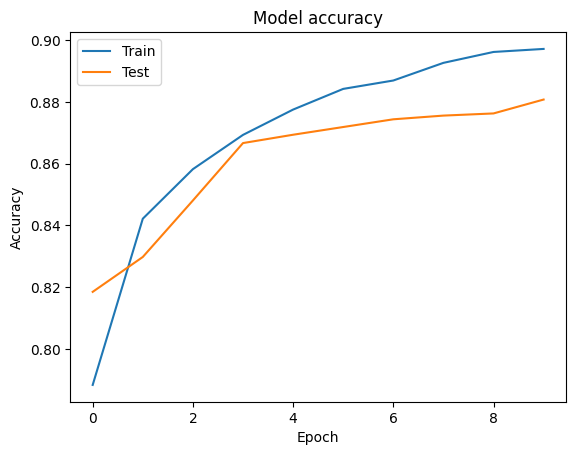

In [32]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

#### Graphical Representation of loss

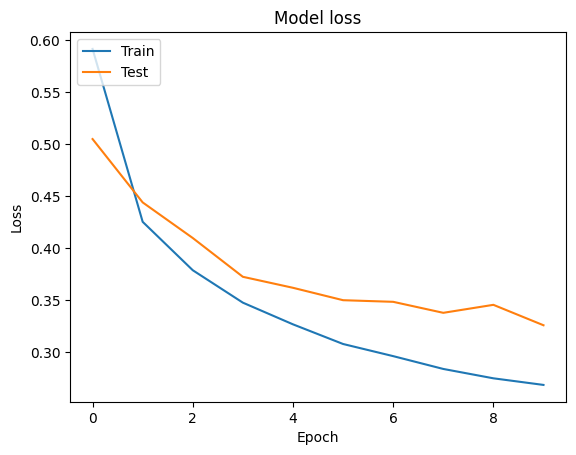

In [33]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()